In [ ]:
#Deep Learning-Based OCR for Medical Prescription Recognition

**Team Members:**  
Baradan Mainali  
Suman Khanal  

This notebook implements a CNN + BiLSTM + Attention OCR pipeline for recognizing text from synthetic medical prescription images.
The workflow includes data preparation, vocabulary construction, image processing, model training, 
evaluation using CER and WER, and qualitative prediction examples.

In [1]:
# Imports + Device
import os
import cv2
import math
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
import matplotlib.pyplot as plt

from PIL import Image
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from jiwer import wer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [2]:
# Load + Prepare data 
# To make the OCR task more trainable, the target text is limited to medicine name + dosage.
labels_path = "synthetic_prescription_dataset/labels.csv"
images_dir = "synthetic_prescription_dataset/images"

labels_df = pd.read_csv(labels_path)

for col in ["medicine", "dosage"]:
    labels_df[col] = labels_df[col].astype(str).str.strip()

# Shorter OCR target: medicine + dosage only
labels_df["line_text"] = (
    labels_df["medicine"] + " " + labels_df["dosage"]
)

grouped_df = labels_df.groupby("image")["line_text"].apply(lambda x: " ".join(x)).reset_index()

grouped_df["text_length"] = grouped_df["line_text"].apply(len)

print(grouped_df.head())
print("Total samples before filtering:", len(grouped_df))
print(grouped_df["text_length"].describe())

# Keep moderate-length samples
grouped_df = grouped_df[grouped_df["text_length"] <= 120].reset_index(drop=True)

print("Total samples after filtering:", len(grouped_df))
print(grouped_df["text_length"].describe())

                   image                                          line_text  \
0     prescription_0.png  Metformin 500mg Azithromycin 200mg Cetirizine ...   
1     prescription_1.png  Metformin 10mg Pantoprazole 40mg Azithromycin ...   
2    prescription_10.png  Paracetamol 500mg Amoxicillin 250mg Diclofenac...   
3   prescription_100.png  Atorvastatin 250mg Omeprazole 500mg Ibuprofen ...   
4  prescription_1000.png  Azithromycin 40mg Diclofenac 250mg Atorvastati...   

   text_length  
0          104  
1          115  
2          119  
3          107  
4           85  
Total samples before filtering: 2000
count    2000.0000
mean      119.0360
std        27.2362
min        61.0000
25%       100.0000
50%       119.0000
75%       138.0000
max       180.0000
Name: text_length, dtype: float64
Total samples after filtering: 1095
count    1095.000000
mean       98.880365
std        16.101975
min        61.000000
25%        86.000000
50%       101.000000
75%       115.000000
max       120.000

In [3]:
# Vocabulary + Helper Functions
all_text = " ".join(grouped_df["line_text"].tolist())
vocab = sorted(list(set(all_text)))

PAD_TOKEN = "<PAD>"
SOS_TOKEN = "<SOS>"
EOS_TOKEN = "<EOS>"

tokens = [PAD_TOKEN,SOS_TOKEN,EOS_TOKEN] + vocab

char_to_idx = {char: idx for idx, char in enumerate(tokens)}
idx_to_char = {idx: char for char, idx in char_to_idx.items()}

PAD_IDX = char_to_idx[PAD_TOKEN]
SOS_IDX = char_to_idx[SOS_TOKEN]
EOS_IDX = char_to_idx[EOS_TOKEN]

def text_to_indices(text):
    return [SOS_IDX] + [char_to_idx[c] for c in text if c in char_to_idx] + [EOS_IDX]

def indices_to_text(indices):
    chars = []
    for idx in indices:
        if idx == EOS_IDX:
            break
        if idx not in [PAD_IDX, SOS_IDX]:
            chars.append(idx_to_char[idx])
    return "".join(chars)

def char_error_rate(gt, pred):
    if len(gt) == 0:
        return 0
    m, n = len(gt), len(pred)
    dp = [[0]*(n+1) for _ in range(m+1)]
    for i in range(m+1): dp[i][0] = i
    for j in range(n+1): dp[0][j] = j
    for i in range(1, m+1):
        for j in range(1, n+1):
            cost = 0 if gt[i-1] == pred[j-1] else 1
            dp[i][j] = min(dp[i-1][j]+1, dp[i][j-1]+1, dp[i-1][j-1]+cost)
    return dp[m][n] / m

#+2 for SOS and EOS
max_text_len = grouped_df["line_text"].apply(len).max() + 2

print("Vocab size:", len(vocab))
print("Max text length:", max_text_len)



Vocab size: 34
Max text length: 122


In [4]:
#Train-Test Split
train_df, test_df = train_test_split(grouped_df, test_size=0.2, random_state=42)

print("Train:",len(train_df), "Test:", len(test_df))


Train: 876 Test: 219


In [6]:
#Dataset Class
class PrescriptionDataset(Dataset):
    def __init__(self, df, image_dir, img_width=512, img_height=64):
        self.df = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.img_width = img_width
        self.img_height = img_height

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img_name = row["image"]
        text = row["line_text"]

        img_path = os.path.join(self.image_dir, img_name)
        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        image = cv2.resize(image, (self.img_width,self.img_height))  # wider image
        image = image.astype(np.float32) / 255.0
        # [1,H,W]
        image = np.expand_dims(image, axis=0)
        
        text_indices = text_to_indices(text)
    
        return torch.tensor(image, dtype=torch.float32), torch.tensor(text_indices,dtype=torch.long), text

In [7]:
#Collate Function
def collate_fn(batch):
    images, labels, texts = zip(*batch)
    images = torch.stack(images)
    label_lengths = [len(l) for l in labels]
    max_len = max(label_lengths)

    padded_lbls = torch.full((len(labels),max_len),PAD_IDX, dtype = torch.long)
    for a, lbl in enumerate(labels):
        padded_lbls[a, :len(lbl)] = lbl
    return images, padded_lbls, label_lengths, texts


In [8]:
#DataLoaders
batch_size = 8

train_dataset = PrescriptionDataset(train_df, images_dir)
test_dataset = PrescriptionDataset(test_df, images_dir)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

Train batches: 110
Test batches: 28


In [9]:
#Attention Module
class Attention(nn.Module):
    def __init__(self, encoder_dim, decoder_dim):
        super().__init__()
        self.encoder_attn = nn.Linear(encoder_dim,decoder_dim)
        self.decoder_attn = nn.Linear(decoder_dim,decoder_dim)
        self.score = nn.Linear(decoder_dim,1)


    def forward(self, encoder_outputs, hidden_state):
        enc_proj = self.encoder_attn(encoder_outputs)
        dec_proj = self.decoder_attn(hidden_state).unsqueeze(1)
        energy = torch.tanh(enc_proj + dec_proj)
        attn_scores = self.score(energy).squeeze(-1)
        attn_weights = torch.softmax(attn_scores, dim=1)
        context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs)
        context = context.squeeze(1)
        return context,attn_weights

In [10]:
#CNN + BiLSTM Encoder
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(1,64,3,1,1), nn.ReLU(), nn.MaxPool2d(2,2),
            nn.Conv2d(64,128,3,1,1), nn.ReLU(), nn.MaxPool2d(2,2),
            nn.Conv2d(128,256,3,1,1), nn.ReLU(),
            nn.Conv2d(256,256,3,1,1), nn.ReLU(), nn.MaxPool2d((2,1)),
            nn.Conv2d(256,512,3,1,1), nn.ReLU(),
            nn.Conv2d(512,512,3,1,1), nn.ReLU(), nn.MaxPool2d((2,1))
        )

        self.bi_lstm = nn.LSTM(
            input_size = 512 * 4,
            hidden_size=256,
            num_layers=2,
            bidirectional=True,
            batch_first=True
        )

    def forward(self, x):
        features = self.cnn(x)
        b,c,h,w = features.size()

        features = features.permute(3,0,1,2)
        features = features.contiguous().view(b,w,c*h)

        outputs,_ = self.bi_lstm(features)
        return outputs

In [11]:
#Attention Decoder
class Decoder(nn.Module):
    def __init__(self, vocab_size, encoder_dim=512, embed_dim=256, hidden_dim=256):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size,embed_dim,padding_idx=PAD_IDX)
        self.attention = Attention(encoder_dim,hidden_dim)
        self.lstm = nn.LSTMCell(embed_dim + encoder_dim, hidden_dim)
        self.fc = nn.Linear(hidden_dim + encoder_dim, vocab_size)

    def forward_step(self, input_token, hidden, cell, encoder_outputs):
        embedded = self.embedding(input_token)
        context, attn_weights = self.attention(encoder_outputs, hidden)
        
        lstm_input = torch.cat([embedded, context], dim=1)
        hidden, cell = self.lstm(lstm_input, (hidden,cell))

        outputs = self.fc(torch.cat([hidden,context], dim=1))
        return outputs, hidden, cell, attn_weights

In [12]:
#Full Model
class OCRAttentionModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()

        self.encoder = Encoder()
        self.decoder = Decoder(vocab_size=vocab_size)

        self.hidden_init = nn.Linear(512,256)
        self.cell_init = nn.Linear(512,256)

    def forward(self, images, targets=None, teacher_forcing_ratio=0.5,max_len=100):
        encoder_outputs = self.encoder(images)
        mean_encoder = encoder_outputs.mean(dim=1)
        
        hidden = torch.tanh(self.hidden_init(mean_encoder))
        cell = torch.tanh(self.cell_init(mean_encoder))

        batch_size = images.size(0)
        if targets is not None:
            seq_len = targets.size(1)
        else:
            seq_len = max_len

        outputs = []
        input_token = torch.full((batch_size,),SOS_IDX,dtype=torch.long, device=images.device)

        for t in range(seq_len):
            output, hidden, cell, _ = self.decoder.forward_step(
                input_token, hidden, cell, encoder_outputs
            )
            outputs.append(output.unsqueeze(1))

            if targets is not None and t < seq_len - 1 and np.random.rand() < teacher_forcing_ratio:
                input_token = targets[:, t + 1]
            else:
                input_token = output.argmax(dim=1)
            
        outputs = torch.cat(outputs, dim=1)
        return outputs




In [13]:
#Model + Loss + Optimizer
model = OCRAttentionModel(vocab_size=len(tokens)).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

print("Model ready")

Model ready


In [14]:
#Training function
def train():
    model.train()
    total_loss = 0

    for images, labels, label_lengths, _ in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        label_lengths = len(train_loader)

        optimizer.zero_grad()

        outputs = model(images, targets=labels, teacher_forcing_ratio=0.5, max_len=labels.size(1))

        output_dim = outputs.size(-1)
        loss = criterion(outputs.view(-1, output_dim), labels.view(-1))

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    return total_loss / label_lengths
        

In [15]:
#Greedy Decoding Function
def greedy_decode(images, max_len=max_text_len):
    model.eval()
    with torch.no_grad():
        outputs = model(images, targets=None, teacher_forcing_ratio=0.0, max_len=max_len)
        preds = outputs.argmax(dim=-1)
    
    decoded_texts = []
    for seq in preds:
        decoded_texts.append(indices_to_text(seq.cpu().numpy().tolist()))
    return decoded_texts

In [16]:
#Evaluation Function
def evaluate():
    model.eval()
    cer_list = []
    wer_list = []
    all_preds = []

    with torch.no_grad():
        for images, _, _, texts in test_loader:
            images = images.to(device)

            pred_texts = greedy_decode(images, max_len=max_text_len)
            all_preds.extend(pred_texts)

            for gt,pred in zip(texts, pred_texts):
                cer_list.append(char_error_rate(gt, pred))
                wer_list.append(wer(gt, pred))

    return np.mean(cer_list), np.mean(wer_list), all_preds

In [17]:
#Run Training
no_epochs = 10

loss_history = []
cer_history = []
wer_history = []

for epoch in range(no_epochs):
    loss = train()
    cer, wer_score, prds_text = evaluate()

    loss_history.append(loss)
    cer_history.append(cer)
    wer_history.append(wer_score)

    print(f"Epoch [{epoch+1}/{no_epochs}]")
    print("Loss:", loss)
    print("CER:", cer)
    print("WER:", wer_score)
    print("-"*40)

Epoch [1/10]
Loss: 2.7486830039457844
CER: 1.1127181332142784
WER: 1.0
----------------------------------------
Epoch [2/10]
Loss: 1.7255654139952226
CER: 0.8667869857943157
WER: 1.08675799086758
----------------------------------------
Epoch [3/10]
Loss: 1.2595288249579344
CER: 0.8431897009648249
WER: 1.1503044140030443
----------------------------------------
Epoch [4/10]
Loss: 0.9842175884680314
CER: 0.7946596035840523
WER: 1.068889976081757
----------------------------------------
Epoch [5/10]
Loss: 0.8293103375218132
CER: 0.7889150993199631
WER: 1.068889976081757
----------------------------------------
Epoch [6/10]
Loss: 0.7043577616864984
CER: 0.7948756518689555
WER: 1.133447488584475
----------------------------------------
Epoch [7/10]
Loss: 0.5954204274849458
CER: 0.764392909973927
WER: 1.1206947162426615
----------------------------------------
Epoch [8/10]
Loss: 0.4920494897799058
CER: 0.7636291254115457
WER: 1.068889976081757
----------------------------------------
Epoch 

In [18]:
#Sample Predictions
sampl_truths = test_df["line_text"].tolist()

for i in range(min(5,len(sampl_truths))):
    print("Actual Truth:",sampl_truths[i])
    print("Predicted  :", prds_text[i])
    print("-" * 60)

Actual Truth: Azithromycin 10mg Amoxicillin 250mg Omeprazole 40mg Ibuprofen 500mg Azithromycin 200mg Amoxicillin 40mg
Predicted  : Aeeprazzlle 200mg Amoxiiiillin 200mg Amoxiiiillin 200mg  bbuprofen 200mg Amoxiiiillin 200mg Amoxiiiillin 200mg  bbuprofen
------------------------------------------------------------
Actual Truth: Paracetamol 10mg Pantoprazole 40mg Atorvastatin 10mg Diclofenac 500mg
Predicted  : Aeeprazzlle 200mg Amoxiiiillin 200mg Amoxiiiillin 200mg  bbuprofen 200mg Amoxiiiillin 200mg Amoxiiiillin 200mg  bbuprofen
------------------------------------------------------------
Actual Truth: Omeprazole 250mg Paracetamol 200mg Atorvastatin 200mg Diclofenac 40mg Metformin 200mg Cetirizine 200mg Ibuprofen 10mg
Predicted  : Aeeprazzlle 200mg Amoxiiiillin 200mg Amoxiiiillin 200mg  bbuprofen 200mg Amoxiiiillin 200mg Amoxiiiillin 200mg  bbuprofen
------------------------------------------------------------
Actual Truth: Pantoprazole 500mg Ibuprofen 250mg Omeprazole 250mg Amoxicillin 

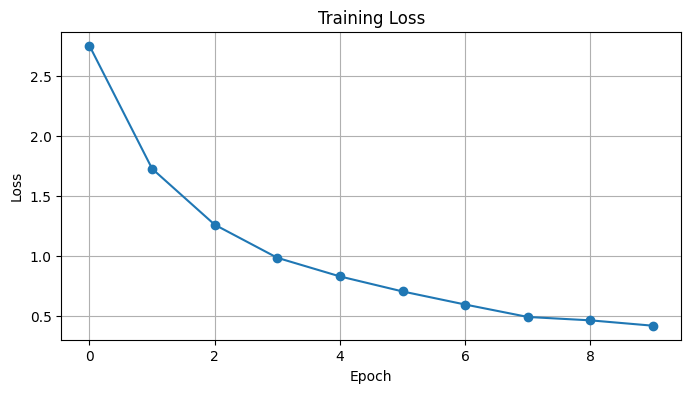

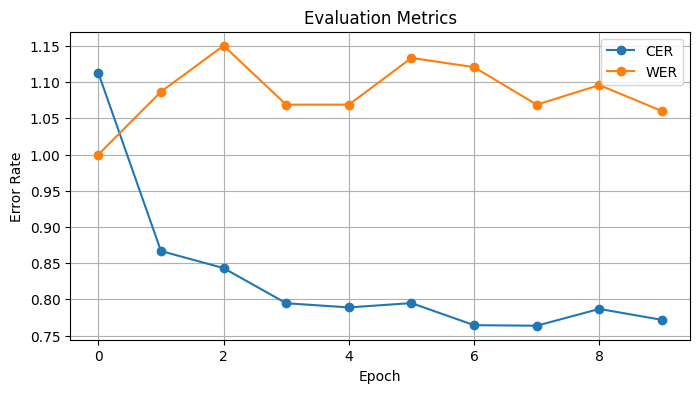

In [19]:
#Plot Results
plt.figure(figsize=(8, 4))
plt.plot(loss_history, marker="o")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(cer_history, marker="o", label="CER")
plt.plot(wer_history, marker="o", label="WER")
plt.title("Evaluation Metrics")
plt.xlabel("Epoch")
plt.ylabel("Error Rate")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
## Conclusion

The CNN + BiLSTM + Attention model is a sequence-based OCR architecture that first extracts visual features
using convolutional layers, then models sequential dependencies with bidirectional LSTMs, and finally uses an
attention decoder to generate the output text one character at a time

Compared with CRNN, this model provides a useful architecture-level comparison
because both are designed for OCR, but they differ in the decoding mechanism :
CRNN uses CTC-based sequence prediction, while this model uses attention-based decoding